In [67]:
# ===============================================
# 📘 Guns Dataset - Missing Value Analysis & Handling
# ===============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder


In [68]:
# --- Load dataset ---
df = pd.read_csv("../data/raw/Guns incident Data.csv")

In [69]:
# ===============================================
# Step 1: Overview of Missing Values
# ===============================================
missing_summary = (
    df.isnull().sum()
    .to_frame('Missing_Count')
    .assign(Missing_Percent=lambda x: 100 * x['Missing_Count'] / len(df),
            Dtype=df.dtypes)
    .query("Missing_Count > 0")
)
print("📊 Missing Value Summary:")
display(missing_summary.reset_index())

📊 Missing Value Summary:


,index,Missing_Count,Missing_Percent,Dtype
0,Education,1422,1.410742,object
1,Age,18,0.017857,float64
2,Place of incident,1384,1.373043,object


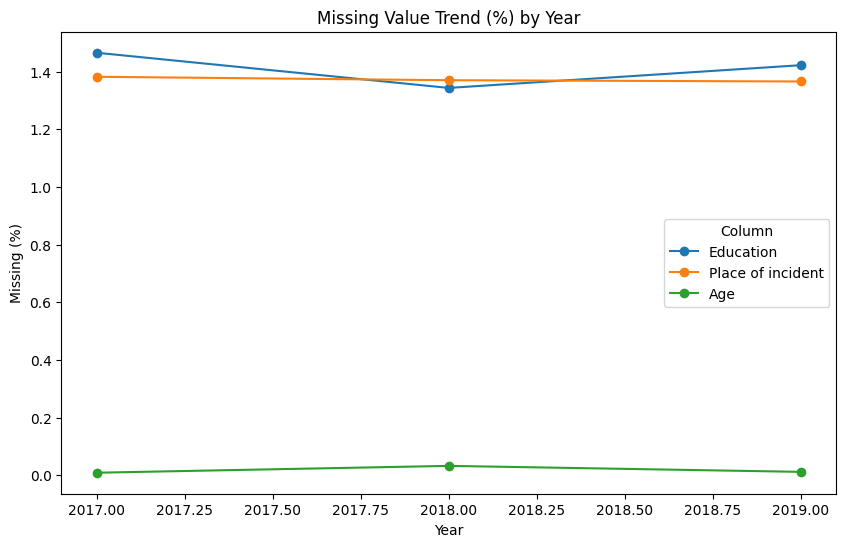

In [70]:
# ===============================================
# Step 2: Trend of Missing Values over Time
# ===============================================
df['Year'] = df['Year'].astype(int)

# Missing rate by year for each affected column
missing_by_year = df.groupby('Year')[['Education', 'Place of incident', 'Age']].apply(
    lambda x: x.isna().mean() * 100
)

missing_by_year.plot(marker='o', figsize=(10, 6))
plt.title("Missing Value Trend (%) by Year")
plt.ylabel("Missing (%)")
plt.xlabel("Year")
plt.legend(title="Column")
plt.show()

In [71]:
# ===============================================
# Step 3: Missingness by Race
# ===============================================

# Create missing flags
df['Education_missing'] = df['Education'].isna()
df['Place_missing'] = df['Place of incident'].isna()

edu_missing_by_race = (
    df.groupby('Race')['Education_missing']
    .mean().mul(100)
    .sort_values(ascending=False)
)
place_missing_by_race = (
    df.groupby('Race')['Place_missing']
    .mean().mul(100)
    .sort_values(ascending=False)
)

print("Education Missing % by Race:")
display(edu_missing_by_race)

print("\nPlace of Incident Missing % by Race:")
display(place_missing_by_race)

Education Missing % by Race:


Race
Asian/Pacific Islander            2.714932
Hispanic                          1.573930
Native American/Native Alaskan    1.526718
White                             1.447831
Black                             1.163290
Name: Education_missing, dtype: float64


Place of Incident Missing % by Race:


Race
Hispanic                          3.103525
Native American/Native Alaskan    2.726281
Asian/Pacific Islander            2.262443
Black                             1.515282
White                             1.050772
Name: Place_missing, dtype: float64

In [72]:
# ===============================================
# Step 4: Correlation Between Missingness
# ===============================================
df['Age_missing'] = df['Age'].isna().astype(int)
df['Education_missing'] = df['Education'].isna().astype(int)
df['Place_missing'] = df['Place of incident'].isna().astype(int)

corr_missing = df[['Age_missing', 'Education_missing', 'Place_missing']].corr()
print("\n🔗 Correlation between Missingness:")
display(corr_missing)


🔗 Correlation between Missingness:


,Age_missing,Education_missing,Place_missing
Age_missing,1.000000,0.092836,-0.001577
Education_missing,0.092836,1.000000,0.004681
Place_missing,-0.001577,0.004681,1.000000


In [73]:
# ===============================================
# Step 5: Handling Missing Values
# ===============================================

# Check skewness of Age
skewness = df['Age'].skew()
print(f"\nSkewness of Age: {skewness:.4f}")

# Age: use mean since skewness < 0.5
df['Age'] = df['Age'].fillna(df['Age'].mean())

# Education: use a placeholder for unknown values
df['Education'] = df['Education'].fillna('Unknown')

# Place of incident: use a placeholder for unspecified
df['Place of incident'] = df['Place of incident'].fillna('Unspecified')

# Remove missing flags
df = df.drop(columns=['Age_missing', 'Education_missing', 'Place_missing'])


Skewness of Age: 0.4288


In [74]:
# ===============================================
# Step 6: Feature Engineering
# ===============================================

# Convert 'Date' to datetime, where Date format is DD-MM-YYYY
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y', errors='coerce')

# --- Create Days of the Week Feature ---
df['day_of_week'] = df['Date'].dt.day_name()

# --- Create isWeekend Feature ---
df['isWeekend'] = df['day_of_week'].isin(['Saturday', 'Sunday']).astype(int)

# Verify no missing values remain
print("\n✅ Remaining Missing Values:")
display(df.isna().sum())

print("\n🎯 Data Cleaning Completed Successfully.")

df.to_csv("../data/cleaned/guns_incident_data_cleaned.csv", index=False)


✅ Remaining Missing Values:


S.No.                 0
Year                  0
Month                 0
Date                  0
Reason                0
Education             0
Sex                   0
Age                   0
Race                  0
Hispanic              0
Place of incident     0
Police involvement    0
day_of_week           0
isWeekend             0
dtype: int64


🎯 Data Cleaning Completed Successfully.


One Hot Encoding

In [75]:
# ===============================================
# 🔹 One-Hot Encoding Pipeline
# ===============================================

# --- Step 1: Automatically detect categorical columns ---
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print("Categorical columns detected:", categorical_cols)

# --- Step 2 (optional): One-hot encode using sklearn for consistency ---
# Useful if you plan to encode new datasets (e.g., test set)
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded_array = encoder.fit_transform(df[categorical_cols])
encoded_df = pd.DataFrame(encoded_array, columns=encoder.get_feature_names_out(categorical_cols))

# Combine with non-categorical columns
numerical_cols = df.drop(columns=categorical_cols).columns
df_final = pd.concat([df[numerical_cols].reset_index(drop=True), encoded_df.reset_index(drop=True)], axis=1)
print("Final dataset shape:", df_final.shape)

# --- Step 4: Export ---
df_final.to_csv("../data/processed/guns_encoded.csv", index=False)
print("✅ Encoded dataset exported as guns_encoded.csv")

Categorical columns detected: ['Reason', 'Education', 'Sex', 'Race', 'Place of incident', 'day_of_week']
Final dataset shape: (100798, 42)
✅ Encoded dataset exported as guns_encoded.csv
